# Water level forcing

**What this shows:** how to create XBeach water level forcing from tidal constituents,
from water level data (for example surge or sea-surface height from an ocean model),
and from both combined.

**Prerequisites:** [Tutorial 4: Adding forcing](../tutorial/04_forcing.ipynb).

**You will learn:**

- how to predict tide from gridded or single-site constituents
- how to use gridded, station and single-point water level data
- how to add surge to the tide with `CombinedWaterLevel`
- how the water level forcing relates to the tide boundary settings

**Data used:** `swaus_tide_cons/` and `tide_cons_station.csv` (tidal constituents),
`ssh_gridded.nc`, `ssh_stations.nc` and `ssh.csv` (sea-surface height).

## Setup

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy_xbeach.grid import RegularGrid
from rompy_xbeach.source import SourceCRSFile

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "water_levels"
shutil.rmtree(OUT_DIR, ignore_errors=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)
period = TimeRange(start="2023-01-01T00", end="2023-01-02T00", interval="1h")
levels = {}


def generate(forcing, name):
    """Write the water level file to its own folder and return it as a series."""
    destdir = OUT_DIR / name
    destdir.mkdir(parents=True)
    params = forcing.get(destdir=destdir, grid=grid, time=period)
    print(f"{name}: {params}")
    df = pd.read_csv(
        destdir / params["zs0file"], sep=r"\s+", header=None, names=["tsec", "zs"]
    )
    times = pd.Index(period.start + pd.to_timedelta(df.tsec, unit="s"), name="time")
    return pd.Series(df.zs.values, index=times, name=name)

## 1. Tide from constituents

`TideConsGrid` predicts the tide from a gridded tide model at the grid centre, here
an OTIS model read with oceantide. `freq` sets the time step of the prediction.

In [2]:
from rompy_xbeach.data.waterlevel import TideConsGrid
from rompy_xbeach.source import SourceCRSOceantide

cons_dir = DATA_DIR / "swaus_tide_cons"
tide_grid = TideConsGrid(
    source=SourceCRSOceantide(
        reader="read_otis_binary",
        kwargs={
            "gfile": cons_dir / "grid_m2s2n2k2k1o1p1q1mmmf",
            "hfile": cons_dir / "h_m2s2n2k2k1o1p1q1mmmf",
            "ufile": cons_dir / "u_m2s2n2k2k1o1p1q1mmmf",
        },
        crs=4326,
    ),
    coords={"x": "lon", "y": "lat"},
    freq="30min",
)
levels["tide (grid cons)"] = generate(tide_grid, "tide_cons_grid")

tide_cons_grid: {'zs0file': 'tide-20230101T000000-20230102T000000.txt', 'tideloc': 1, 'tidelen': 49}


`TideConsPoint` uses amplitude and phase per constituent at one site, for example
from a harmonic analysis of a tide gauge.

In [3]:
from rompy_xbeach.data.waterlevel import TideConsPoint
from rompy_xbeach.source import SourceTideConsPointCSV

print((DATA_DIR / "tide_cons_station.csv").read_text())
tide_point = TideConsPoint(
    source=SourceTideConsPointCSV(filename=DATA_DIR / "tide_cons_station.csv")
)
levels["tide (site cons)"] = generate(tide_point, "tide_cons_point")

constituent,amplitude,phase
M2,0.04248529,63.434948
S2,0.046141084,60.101093
N2,0.016552946,115.016884
K2,0.015000001,53.1301
K1,0.18253767,184.39871
O1,0.12913945,177.33699
P1,0.057008773,178.9949
Q1,0.028442925,169.87532
MM,0.002,90.0
MF,0.002,90.0

tide_cons_point: {'zs0file': 'tide-20230101T000000-20230102T000000.txt', 'tideloc': 1, 'tidelen': 25}


## 2. Water level data

The `WaterLevel...` classes read a water level variable directly, named in
`variables`. Gridded data is sampled at the grid centre:

In [4]:
from rompy_xbeach.data.waterlevel import WaterLevelGrid

ssh_grid = WaterLevelGrid(
    source=SourceCRSFile(
        uri=DATA_DIR / "ssh_gridded.nc", crs=4326, x_dim="lon", y_dim="lat"
    ),
    coords={"x": "lon", "y": "lat"},
    variables=["ssh"],
)
levels["ssh (grid)"] = generate(ssh_grid, "ssh_grid")

ssh_grid: {'zs0file': 'tide-20230101T000000-20230102T000000.txt', 'tideloc': 1, 'tidelen': 25}


Station data is interpolated between sites, as for winds and waves:

In [5]:
from rompy_xbeach.data.waterlevel import WaterLevelStation

ssh_station = WaterLevelStation(
    source=SourceCRSFile(
        uri=DATA_DIR / "ssh_stations.nc", crs=4326, x_dim="lon", y_dim="lat"
    ),
    coords={"s": "site", "x": "lon", "y": "lat"},
    variables=["ssh"],
)
levels["ssh (stations)"] = generate(ssh_station, "ssh_station")

ssh_station: {'zs0file': 'tide-20230101T000000-20230102T000000.txt', 'tideloc': 1, 'tidelen': 25}


A single timeseries is used as it is:

In [6]:
from rompy.core.source import SourceTimeseriesCSV
from rompy_xbeach.data.waterlevel import WaterLevelPoint

ssh_point = WaterLevelPoint(
    source=SourceTimeseriesCSV(filename=DATA_DIR / "ssh.csv", tcol="time"),
    variables=["ssh"],
)
levels["ssh (CSV)"] = generate(ssh_point, "ssh_point")

ssh_point: {'zs0file': 'tide-20230101T000000-20230102T000000.txt', 'tideloc': 1, 'tidelen': 25}


## 3. Surge plus tide: `CombinedWaterLevel`

Ocean model sea-surface height often excludes the tide. `CombinedWaterLevel`
predicts the tide from constituents and adds the water level interpolated to the
tide times.

In [7]:
from rompy_xbeach.data.waterlevel import CombinedWaterLevel

combined = CombinedWaterLevel(tide=tide_grid, waterlevel=ssh_grid)
levels["tide + ssh (combined)"] = generate(combined, "combined")

combined: {'zs0file': 'tide-20230101T000000-20230102T000000.txt', 'tideloc': 1, 'tidelen': 49}


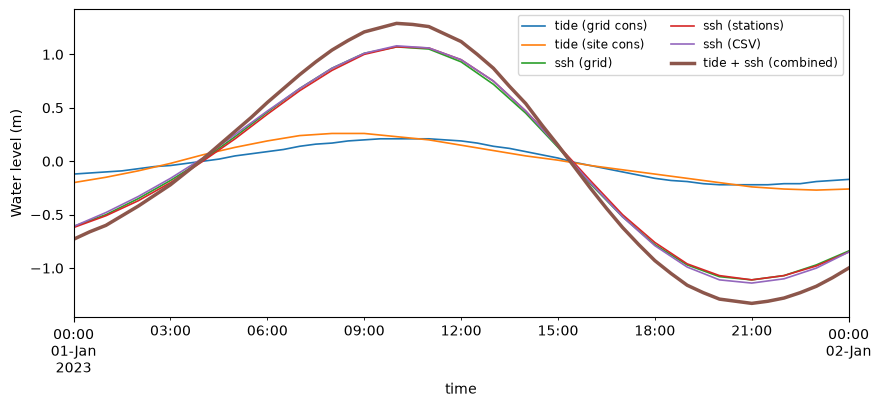

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, series in levels.items():
    series.plot(ax=ax, label=name, linewidth=2.5 if "combined" in name else 1.2)
ax.set_ylabel("Water level (m)")
ax.legend(ncol=2, fontsize="small")
plt.show()

## 4. Using water levels in a model

Water level forcing goes in `input.tide`, and any of the classes above can be used.
In YAML, `CombinedWaterLevel` has `model_type: combined_water_level`.

The forcing sets `tideloc = 1`, one water level signal at the offshore boundary.
Leave `tide_boundary.tideloc` unset so it does not override this, and use
`tide_boundary` for the other settings, such as `tidetype` or `paulrevere`.

In [9]:
from rompy_xbeach.config import DataInterface

data = DataInterface(tide=combined.model_dump())
type(data.tide).__name__

'CombinedWaterLevel'

## Summary

| Data | Class |
|---|---|
| Gridded tidal constituents | `TideConsGrid` |
| Constituents at one site | `TideConsPoint` |
| Gridded water levels | `WaterLevelGrid` |
| Water levels at stations | `WaterLevelStation` |
| Water level timeseries | `WaterLevelPoint` |
| Water levels plus tide | `CombinedWaterLevel` |